In [1]:
!pip install optuna ipywidgets
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import optuna
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, VotingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.compose import TransformedTargetRegressor



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 47.6 MB/s eta 0:00:00


In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
df = pd.read_csv('ECC_An_Final_with_Cost.csv')

X = df.drop(columns=['Second Stress', 'Second Strain', 'Total_Cost'])
X = X.loc[:, (X != 0).any(axis=0)]

y_stress = df['Second Stress']
y_strain = df['Second Strain']
y_cost = df['Total_Cost']

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model_stress = Pipeline([
    ('scaler', StandardScaler()),
    ('et', ExtraTreesRegressor(n_estimators=200, random_state=42))
])

model_strain = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('rf', RandomForestRegressor(n_estimators=500, random_state=42))
])

model_cost = LinearRegression()

cv_stress = cross_val_score(model_stress, X, y_stress, cv=kf, scoring='r2')
cv_strain = cross_val_score(model_strain, X, y_strain, cv=kf, scoring='r2')
cv_cost   = cross_val_score(model_cost, X, y_cost, cv=kf, scoring='r2')

print(f"Stress R^2 : {cv_stress.mean():.4f}")
print(f"Strain R^2 : {cv_strain.mean():.4f} (Maximized via Interactions)")
print(f"Deterministic Cost R^2: {cv_cost.mean():.4f}")
print("="*60)

model_stress.fit(X, y_stress)
model_strain.fit(X, y_strain)

Stress R^2 : 0.7576
Strain R^2 : 0.5792 (Maximized via Interactions)
Deterministic Cost R^2: 1.0000


Pipeline(steps=[('scaler', StandardScaler()),
                ('poly',
                 PolynomialFeatures(include_bias=False, interaction_only=True)),
                ('rf',
                 RandomForestRegressor(n_estimators=500, random_state=42))])

In [7]:
prices = {
    'Cement': 0.30420, 'Water': 0.00220, 'Sand': 0.01980, 'Fly ash F': 0.01349,
    'GGBS': 0.07860, 'Silica Fume': 0.39160, 'Water Reducer / SP': 3.91600, 'Fiber': 4.00000
}

style = {'description_width': '150px'}
layout = widgets.Layout(width='400px')

w_cem = widgets.FloatSlider(value=400, min=200, max=800, step=10, description='Cement (kg/m³):', style=style, layout=layout)
w_wat = widgets.FloatSlider(value=250, min=150, max=400, step=5, description='Water (kg/m³):', style=style, layout=layout)
w_san = widgets.FloatSlider(value=450, min=200, max=800, step=10, description='Sand (kg/m³):', style=style, layout=layout)
w_fly = widgets.FloatSlider(value=600, min=0, max=1000, step=10, description='Fly Ash F (kg/m³):', style=style, layout=layout)
w_ggb = widgets.FloatSlider(value=0, min=0, max=400, step=10, description='GGBS (kg/m³):', style=style, layout=layout)
w_sil = widgets.FloatSlider(value=0, min=0, max=100, step=5, description='Silica Fume (kg/m³):', style=style, layout=layout)
w_sp  = widgets.FloatSlider(value=5, min=0, max=20, step=0.5, description='SP / HRWR (kg/m³):', style=style, layout=layout)
w_fib = widgets.FloatSlider(value=26, min=10, max=40, step=1, description='PVA Fiber (kg/m³):', style=style, layout=layout)

output_box = widgets.Output()
btn_predict = widgets.Button(description="Predict Performance", button_style='success', layout=widgets.Layout(width='400px', height='40px'))

def on_predict_clicked(b):
    with output_box:
        clear_output()

        binder = w_cem.value + w_fly.value + w_ggb.value + w_sil.value
        w_b = w_wat.value / binder if binder > 0 else 1.0
        c_b = w_cem.value / binder if binder > 0 else 1.0
        w_c = w_wat.value / w_cem.value if w_cem.value > 0 else 1.0
        fiber_vol = w_fib.value / 1300

        input_data = pd.DataFrame([{
            'Fiber Volume': fiber_vol, 'Length (mm)': 12.0, 'Diameter (mm)': 0.04,
            'L/D': 300, 'Shape Factor': 0.733, 'RI': fiber_vol * 300,
            'Cement': w_cem.value, 'Water': w_wat.value, 'Sand': w_san.value,
            'Fly ash F': w_fly.value, 'GGBS': w_ggb.value, 'Silica Fume': w_sil.value,
            'Water Reducer / SP': w_sp.value, 'Fiber': w_fib.value,
            'C/B': c_b, 'W/C': w_c, 'W/B': w_b
        }])

        for col in X.columns:
            if col not in input_data.columns: input_data[col] = 0.0
        input_data = input_data[X.columns]

        pred_stress = model_stress.predict(input_data)[0]
        pred_strain = model_strain.predict(input_data)[0]
        cost = (w_cem.value*prices['Cement'] + w_wat.value*prices['Water'] + w_san.value*prices['Sand'] +
                w_fly.value*prices['Fly ash F'] + w_ggb.value*prices['GGBS'] + w_sil.value*prices['Silica Fume'] +
                w_sp.value*prices['Water Reducer / SP'] + w_fib.value*prices['Fiber'])

        print("Results:")
        print(f"Stress: {pred_stress:.2f} MPa")
        print(f"Strain: {pred_strain:.4f} mm/mm ({pred_strain*100:.2f}%)")
        print(f"Material Cost: ${cost:.2f} per m^3")

btn_predict.on_click(on_predict_clicked)

ui = widgets.VBox([
    widgets.HTML("<h3>ECC Predictor (Forward Pass)</h3>"),
    w_cem, w_wat, w_san, w_fly, w_ggb, w_sil, w_sp, w_fib,
    btn_predict, output_box
])
display(ui)


Goals: [1] Maximize Stress  [2] Maximize Strain  [3] Minimize Cost
Found 130 Optimal Pareto Mixes

Best Recipe:
Cost: $160.73/m³ (Absolute Cheapest on Pareto Front)
Stress: 4.49 MPa
Strain: 2.05%

Ingredients required (kg/m^3):
 - Cement      : 215.6
 - Water       : 151.0
 - Sand        : 227.5
 - Fly ash F   : 411.3
 - GGBS        : 61.7
 - Silica Fume : 16.9
 - SP          : 2.1
 - Fiber       : 16.3


In [11]:
def run_inverse_pass(target_stress, target_strain_percent, max_cost):
    print(f"Targets  -> Stress: >= {target_stress} MPa | Strain: >= {target_strain_percent}% | Cost: <= ${max_cost}")

    target_strain = target_strain_percent / 100.0 # Convert back to decimal for the model

    def objective(trial):
        cement = trial.suggest_float('Cement', 200, 800)
        water = trial.suggest_float('Water', 150, 400)
        sand = trial.suggest_float('Sand', 200, 800)
        fly_ash = trial.suggest_float('Fly ash F', 0, 1000)
        ggbs = trial.suggest_float('GGBS', 0, 400)
        silica = trial.suggest_float('Silica Fume', 0, 100)
        sp = trial.suggest_float('Water Reducer / SP', 2, 20)
        fiber = trial.suggest_float('Fiber', 10, 40)

        binder = cement + fly_ash + ggbs + silica
        if binder == 0: return 0, 0, 9999
        w_b = water / binder
        if w_b < 0.15 or w_b > 0.60: return 0, 0, 9999

        c_b = cement / binder
        w_c = water / cement if cement > 0 else 1.0
        f_vol = fiber / 1300

        virtual_mix = pd.DataFrame([{
            'Fiber Volume': f_vol, 'Length (mm)': 12.0, 'Diameter (mm)': 0.04,
            'L/D': 300, 'Shape Factor': 0.733, 'RI': f_vol * 300,
            'Cement': cement, 'Water': water, 'Sand': sand,
            'Fly ash F': fly_ash, 'GGBS': ggbs, 'Silica Fume': silica,
            'Water Reducer / SP': sp, 'Fiber': fiber,
            'C/B': c_b, 'W/C': w_c, 'W/B': w_b
        }])[X.columns]

        stress = model_stress.predict(virtual_mix)[0]
        strain = model_strain.predict(virtual_mix)[0]
        cost = (cement*prices['Cement'] + water*prices['Water'] + sand*prices['Sand'] +
                fly_ash*prices['Fly ash F'] + ggbs*prices['GGBS'] + silica*prices['Silica Fume'] +
                sp*prices['Water Reducer / SP'] + fiber*prices['Fiber'])

        return stress, strain, cost

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(directions=["maximize", "maximize", "minimize"])
    study.optimize(objective, n_trials=1500)

    valid_mixes = []
    for t in study.best_trials:
        t_stress, t_strain, t_cost = t.values
        if t_stress >= target_stress and t_strain >= target_strain and t_cost <= max_cost:
            valid_mixes.append(t)

    if len(valid_mixes) == 0:
        print("\nStrict targets could not be perfectly met. Here are the 5 closest mixes:")
        valid_mixes = sorted(study.best_trials, key=lambda t:
            max(0, target_stress - t.values[0]) + max(0, target_strain - t.values[1])*100 + max(0, t.values[2] - max_cost)
        )
    else:
        valid_mixes = sorted(valid_mixes, key=lambda t: t.values[2])
        print(f"\nFound {len(valid_mixes)} recipes meeting your strict requirements!")

    print("\nTop 5 Recommended Recipes\n")
    for i, mix in enumerate(valid_mixes[:5]):
        print(f"Recipe #{i+1}")
        print(f"Stress: {mix.values[0]:.2f} MPa")
        print(f"Strain: {mix.values[1]*100:.2f}%")
        print(f"Cost: ${mix.values[2]:.2f}/m³")
        print("Ingredients (kg/m³):")
        print(f" Cement: {mix.params['Cement']:.1f} | Water: {mix.params['Water']:.1f} | Sand: {mix.params['Sand']:.1f}")
        print(f" Fly Ash: {mix.params['Fly ash F']:.1f} | GGBS: {mix.params['GGBS']:.1f} | Silica Fume: {mix.params['Silica Fume']:.1f}")
        print(f" Fiber: {mix.params['Fiber']:.1f} | SP: {mix.params['Water Reducer / SP']:.1f}\n")

USER_TARGET_STRESS = 4.0
USER_TARGET_STRAIN = 2.0
USER_MAX_COST = 300.0

run_inverse_pass(target_stress=USER_TARGET_STRESS, target_strain_percent=USER_TARGET_STRAIN, max_cost=USER_MAX_COST)

Targets  -> Stress: >= 4.0 MPa | Strain: >= 2.0% | Cost: <= $300.0

Found 78 recipes meeting your strict requirements!

Top 5 Recommended Recipes

Recipe #1
Stress: 4.50 MPa
Strain: 3.05%
Cost: $141.60/m³
Ingredients (kg/m³):
 Cement: 214.8 | Water: 201.7 | Sand: 518.6
 Fly Ash: 972.6 | GGBS: 20.1 | Silica Fume: 0.5
 Fiber: 10.3 | SP: 2.4

Recipe #2
Stress: 4.31 MPa
Strain: 3.17%
Cost: $147.16/m³
Ingredients (kg/m³):
 Cement: 218.8 | Water: 201.7 | Sand: 312.1
 Fly Ash: 972.6 | GGBS: 20.1 | Silica Fume: 0.5
 Fiber: 11.0 | SP: 3.8

Recipe #3
Stress: 4.31 MPa
Strain: 3.17%
Cost: $147.16/m³
Ingredients (kg/m³):
 Cement: 218.8 | Water: 201.7 | Sand: 312.1
 Fly Ash: 972.6 | GGBS: 20.1 | Silica Fume: 0.5
 Fiber: 11.0 | SP: 3.8

Recipe #4
Stress: 4.71 MPa
Strain: 2.27%
Cost: $149.11/m³
Ingredients (kg/m³):
 Cement: 214.8 | Water: 166.2 | Sand: 518.6
 Fly Ash: 732.2 | GGBS: 20.1 | Silica Fume: 0.5
 Fiber: 11.0 | SP: 4.5

Recipe #5
Stress: 4.25 MPa
Strain: 3.28%
Cost: $157.58/m³
Ingredients (kg

Running Monte Carlo Simulation (1000 batches)...
Simulating a human batching error of ±3.0% per ingredient.

Validation Results:
Average Simulated Stress: 4.74 MPa (Target: 4.0)
Average Simulated Strain: 3.06% (Target: 2.0%)
Overall Reliability Score: 100.0%
Verdict: HIGHLY ROBUST. This recipe is safe to physically mix in the lab.


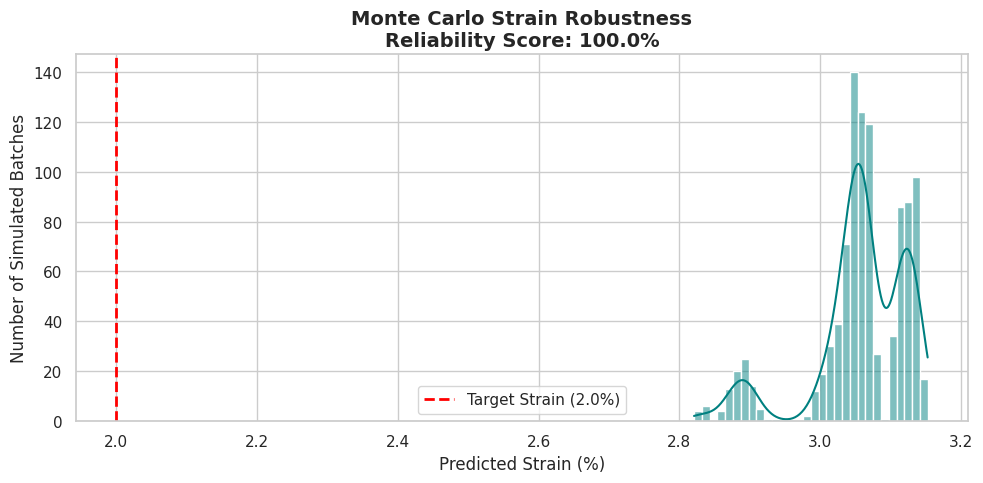

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


ai_recipe = {
    'Cement': 214.8,
    'Water': 201.7,
    'Sand': 518.6,
    'Fly ash F': 972.6,
    'GGBS': 20.1,
    'Silica Fume': 0.5,
    'Water Reducer / SP': 10.4,
    'Fiber': 2.4
}

TARGET_STRESS = 4.0
TARGET_STRAIN = 2.0


def validate_inverse_recipe(recipe, target_stress, target_strain_percent, num_simulations=1000, error_margin=0.03):
    print(f"Running Monte Carlo Simulation ({num_simulations} batches)...")
    print(f"Simulating a human batching error of ±{error_margin*100}% per ingredient.\n")

    target_strain = target_strain_percent / 100.0
    simulated_batches = []

    for _ in range(num_simulations):
        #Applying random Gaussian noise to simulate scale/measuring errors in the lab
        sim_cem = recipe['Cement'] * np.random.normal(1.0, error_margin/3)
        sim_wat = recipe['Water'] * np.random.normal(1.0, error_margin/3)
        sim_san = recipe['Sand'] * np.random.normal(1.0, error_margin/3)
        sim_fly = recipe['Fly ash F'] * np.random.normal(1.0, error_margin/3)
        sim_ggb = recipe['GGBS'] * np.random.normal(1.0, error_margin/3)
        sim_sil = recipe['Silica Fume'] * np.random.normal(1.0, error_margin/3)
        sim_sp  = recipe['Water Reducer / SP'] * np.random.normal(1.0, error_margin/3)
        sim_fib = recipe['Fiber'] * np.random.normal(1.0, error_margin/3)

        #Calculating derived physics parameters for this specific noisy batch
        binder = sim_cem + sim_fly + sim_ggb + sim_sil
        w_b = sim_wat / binder if binder > 0 else 1.0
        c_b = sim_cem / binder if binder > 0 else 1.0
        w_c = sim_wat / sim_cem if sim_cem > 0 else 1.0
        f_vol = sim_fib / 1300

        simulated_batches.append({
            'Fiber Volume': f_vol, 'Length (mm)': 12.0, 'Diameter (mm)': 0.04,
            'L/D': 300, 'Shape Factor': 0.733, 'RI': f_vol * 300,
            'Cement': sim_cem, 'Water': sim_wat, 'Sand': sim_san,
            'Fly ash F': sim_fly, 'GGBS': sim_ggb, 'Silica Fume': sim_sil,
            'Water Reducer / SP': sim_sp, 'Fiber': sim_fib,
            'C/B': c_b, 'W/C': w_c, 'W/B': w_b
        })

    df_sim = pd.DataFrame(simulated_batches)[X.columns]

    sim_stresses = model_stress.predict(df_sim)
    sim_strains = model_strain.predict(df_sim)

    success_stress = sim_stresses >= target_stress
    success_strain = sim_strains >= target_strain
    overall_success = success_stress & success_strain

    reliability_score = (np.sum(overall_success) / num_simulations) * 100

    print("Validation Results:")
    print(f"Average Simulated Stress: {np.mean(sim_stresses):.2f} MPa (Target: {target_stress})")
    print(f"Average Simulated Strain: {np.mean(sim_strains)*100:.2f}% (Target: {target_strain_percent}%)")
    print(f"Overall Reliability Score: {reliability_score:.1f}%")

    if reliability_score >= 85:
        print("Verdict: HIGHLY ROBUST. This recipe is safe to physically mix in the lab.")
    elif reliability_score >= 50:
        print("Verdict: MARGINAL. The recipe meets targets but is sensitive to measuring errors.")
    else:
        print("Verdict: UNSTABLE. This is a mathematical anomaly; do not use in production.")

    plt.figure(figsize=(10, 5))
    sns.set_theme(style="whitegrid")

    sns.histplot(sim_strains*100, kde=True, color='teal', bins=30)
    plt.axvline(x=target_strain_percent, color='red', linestyle='--', linewidth=2, label=f'Target Strain ({target_strain_percent}%)')
    plt.title(f'Monte Carlo Strain Robustness\nReliability Score: {reliability_score:.1f}%', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Strain (%)', fontsize=12)
    plt.ylabel('Number of Simulated Batches', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

validate_inverse_recipe(ai_recipe, TARGET_STRESS, TARGET_STRAIN)